# Memory-Augmented Persistent Agents

This notebook consolidates key concepts from three presentations:
1. *Why Is Memory Essential for Agentic Behavior*
2. *Comparing Techniques and Frameworks for Persistent Memory*
3. *End-to-end Demo: A Multi-agent System with Persistent Memory*

**Prerequisites:** Vector Databases · RAG · Agentic Frameworks (LangChain, LlamaIndex, CrewAI)

In [1]:
from IPython.display import HTML, display
from PIL import Image as PILImage
import base64, io, os

ASSETS = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'assets')

def show(filename, pct=100):
    path = os.path.join(ASSETS, filename)
    img = PILImage.open(path)
    w, h = img.size
    new_w = int(w * pct / 100)
    new_h = int(h * pct / 100)
    img = img.resize((new_w, new_h), PILImage.LANCZOS)
    buf = io.BytesIO()
    img.save(buf, format='PNG')
    b64 = base64.b64encode(buf.getvalue()).decode()
    display(HTML(f'<div style="text-align:center"><img src="data:image/png;base64,{b64}" width="{new_w}" height="{new_h}"/></div>'))

---
## Part 1: Why Is Memory Essential for Agentic Behavior

### What Are AI Agents?

> AI Agents are designed to operate autonomously within complex environments.

An agent perceives its environment through **sensors**, reasons using an **LLM**, and acts on the world via **actuators**. This perception-action cycle is the foundation of all agentic systems.

*Source: [Wikipedia — AI agent](https://en.wikipedia.org/wiki/AI_agent)*

### The Perception-Action Cycle


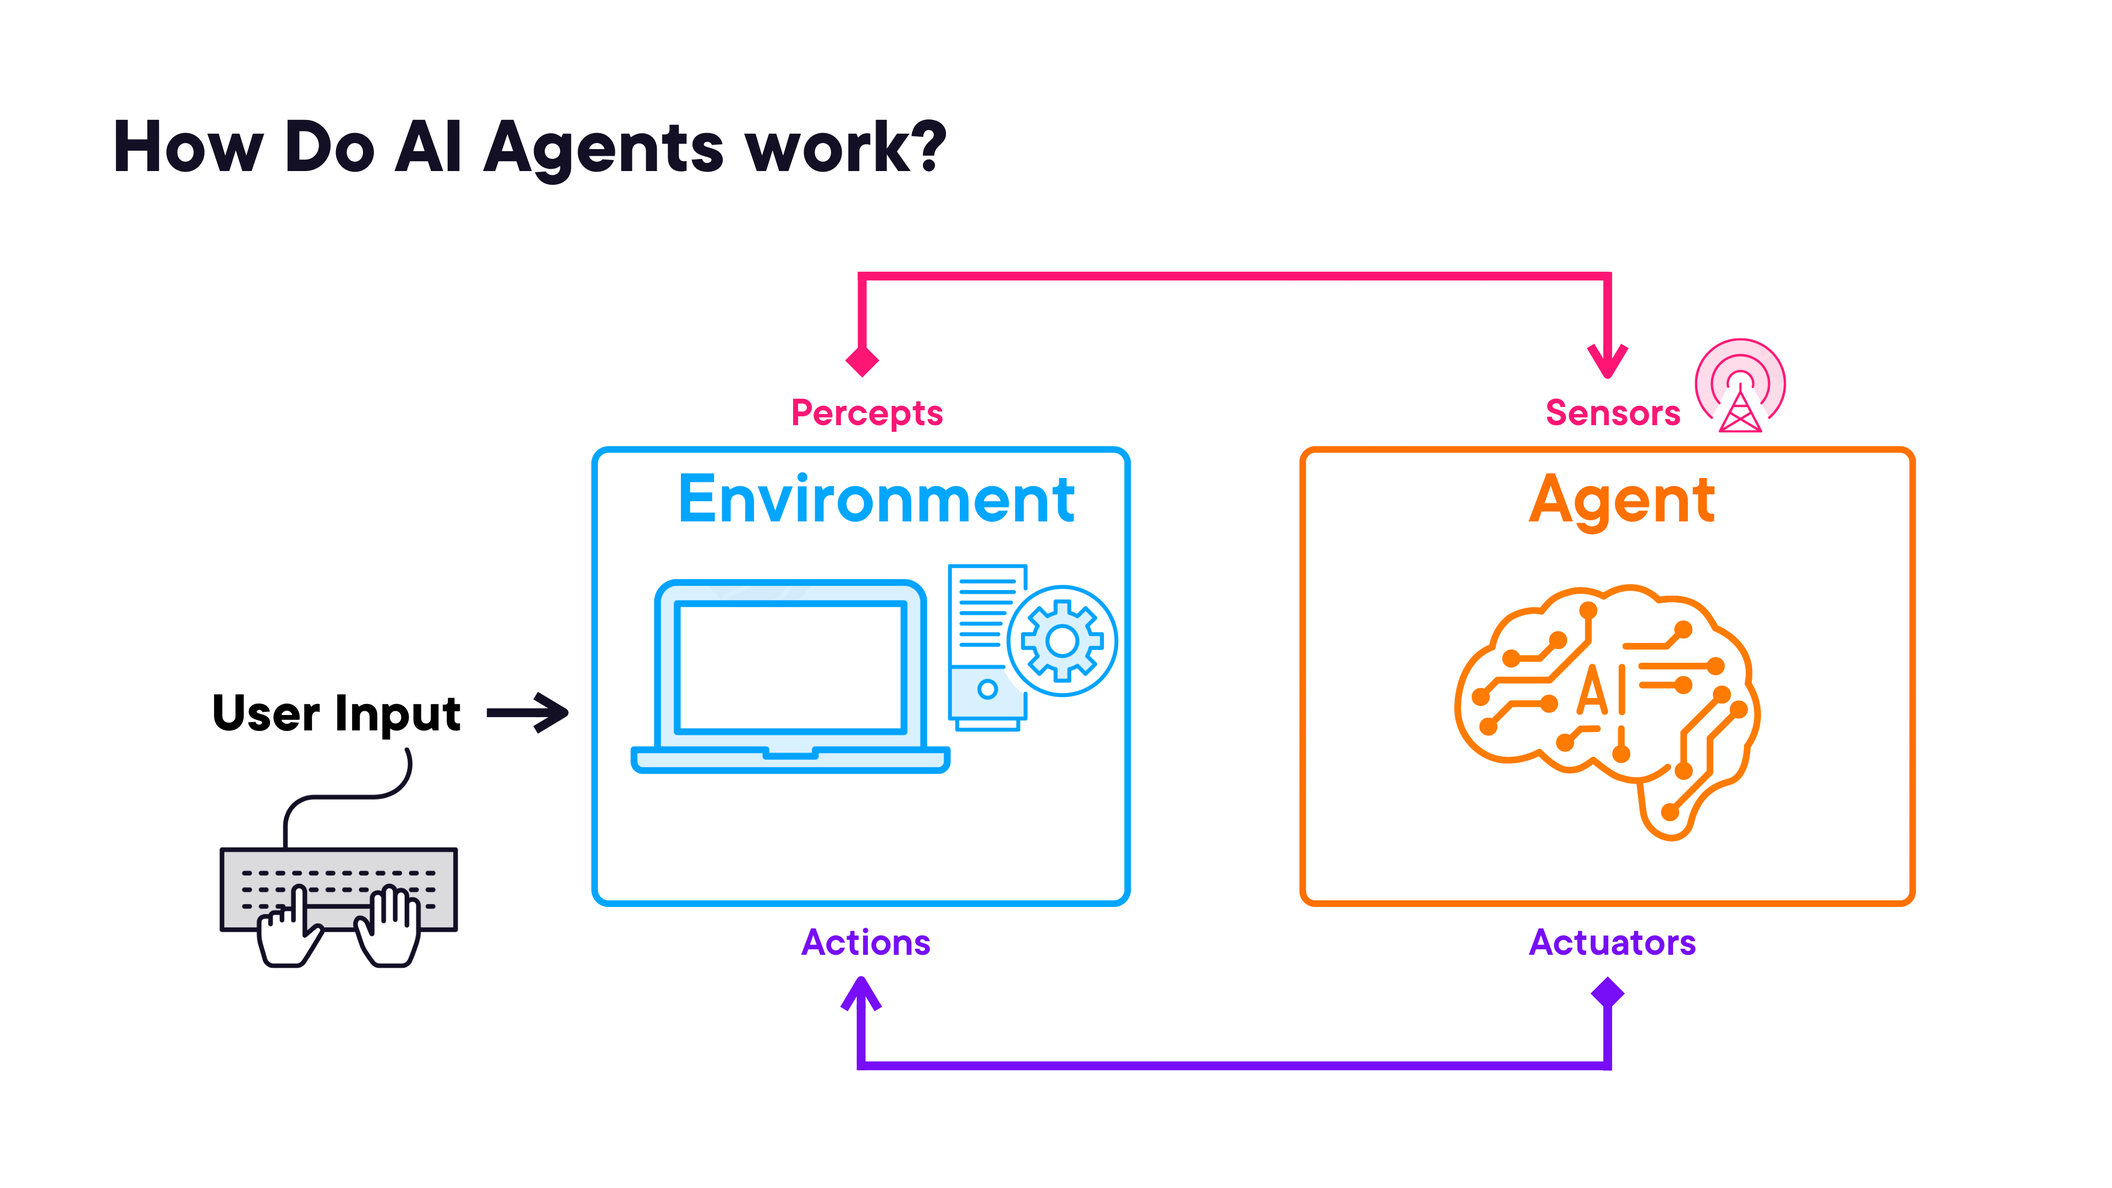

In [2]:
show('agent-perception-action-cycle.png', 55)

| Stage | Component | Description |
|-------|-----------|-------------|
| Input | **Sensors / Percepts** | Receive information from the environment |
| Processing | **Agent (LLM)** | Reason, plan, and decide the next action |
| Output | **Actuators / Actions** | Execute decisions and affect the environment |

### Agents Workflow

> A sequence of steps where multiple agents collaborate to perform a task.


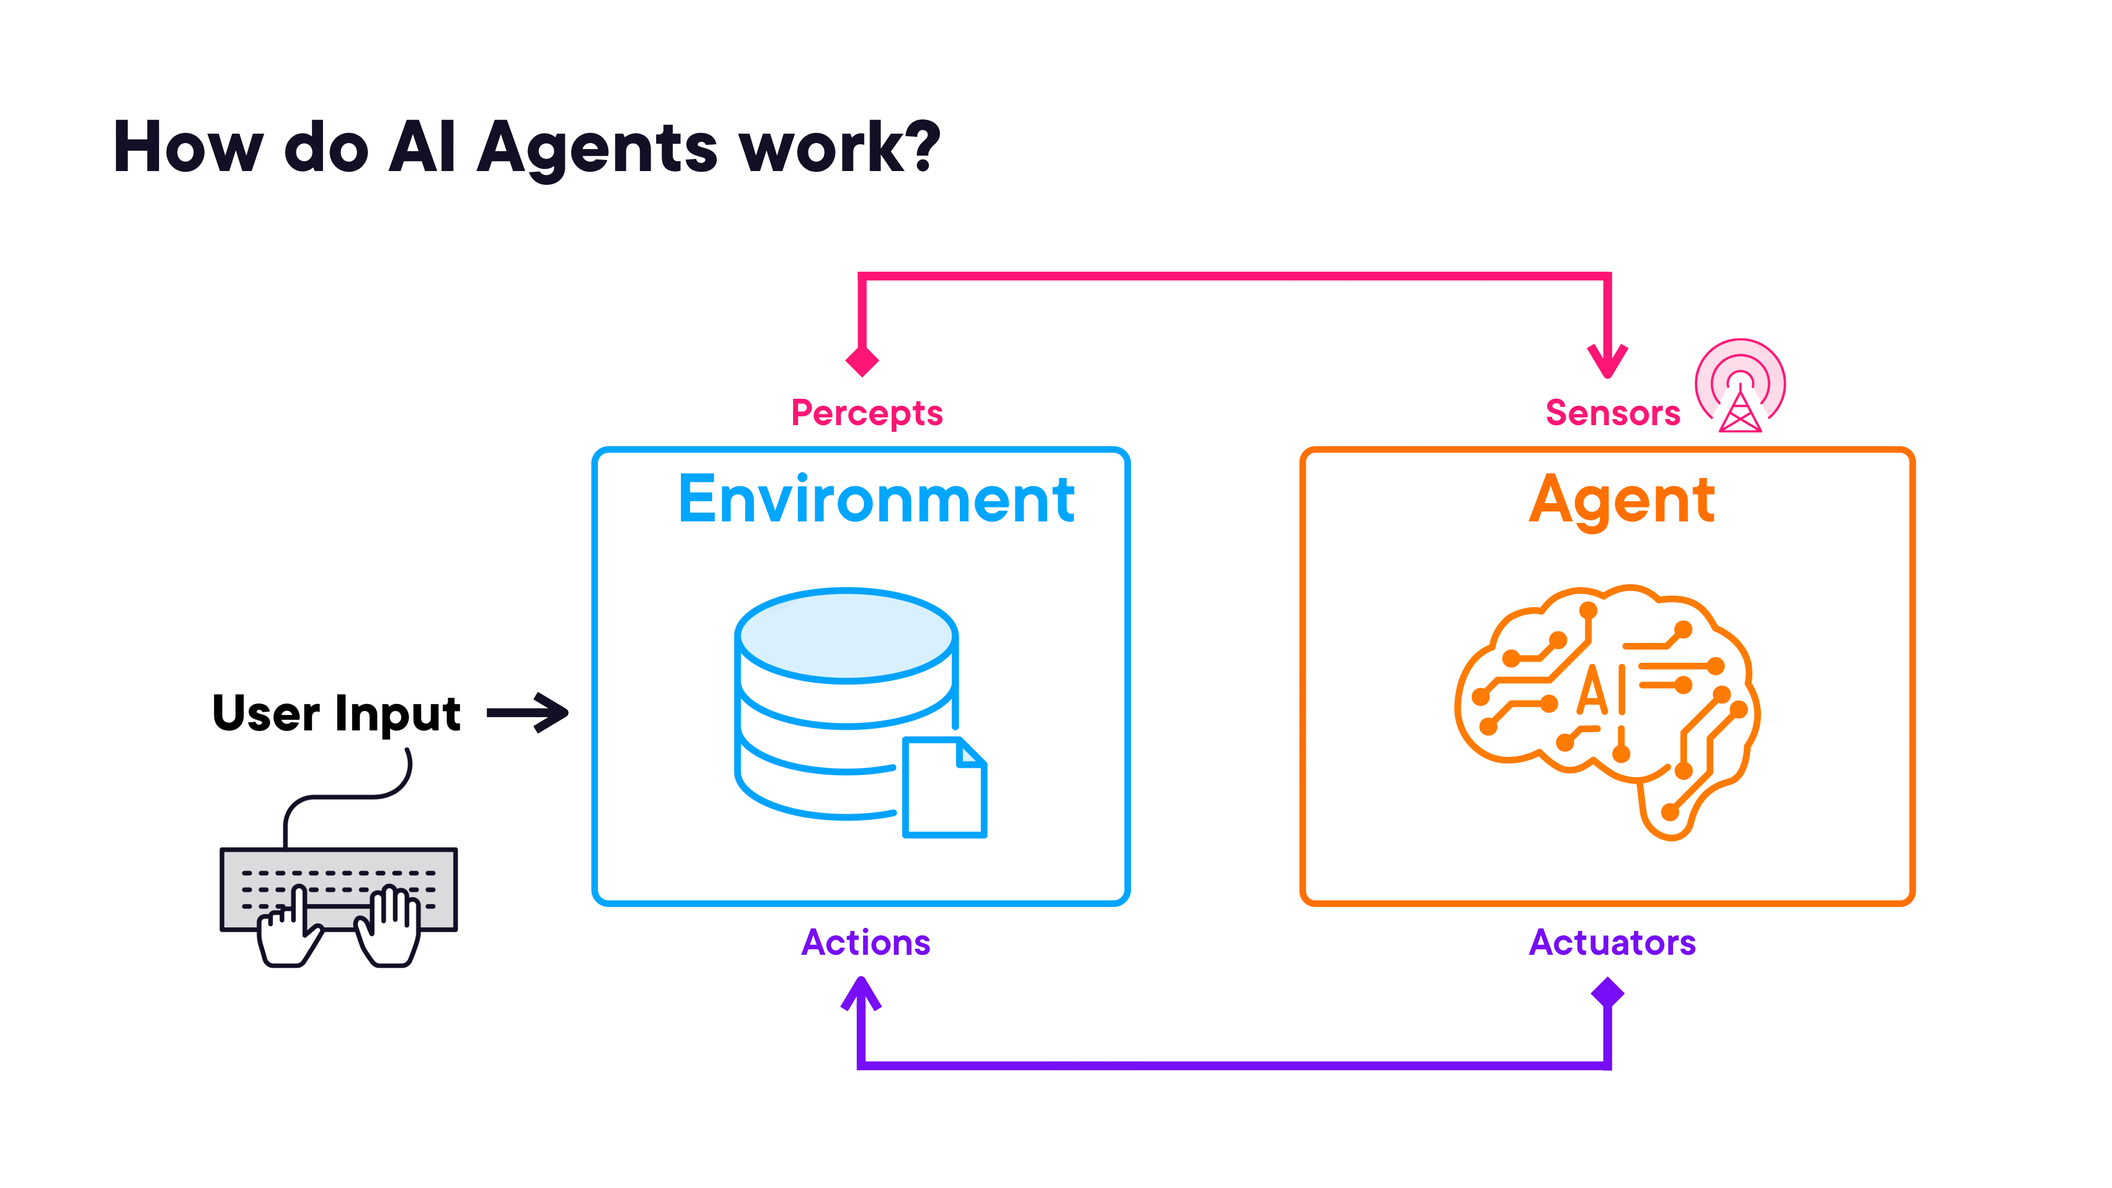

In [3]:
show('agents-workflow.png', 55)

### The Core Problem: LLMs Are Stateless

> Language Models do not have real-time awareness.

By default, every LLM call is **independent** — no awareness of past interactions, no persistent state. This means:
- Each conversation starts from zero
- No user preferences are remembered
- Multi-step tasks cannot be resumed
- The agent cannot improve over time

This is the fundamental motivation for **memory-augmented agents**.

### The Sense → Reason → Act Model

The canonical agent loop operates in three stages:

| Stage | Description |
|-------|-------------|
| **Sense** | Gather inputs from the environment via Sensors |
| **Reason** | Use LLM + memory for decision-making and planning |
| **Act** | Execute via Actuators/Effectors (actions, API calls, workflows) |

Memory sits inside the **Reason** stage — it provides the context that spans multiple loop iterations and sessions.

### Stateless Agent: Simple Reflex Agent


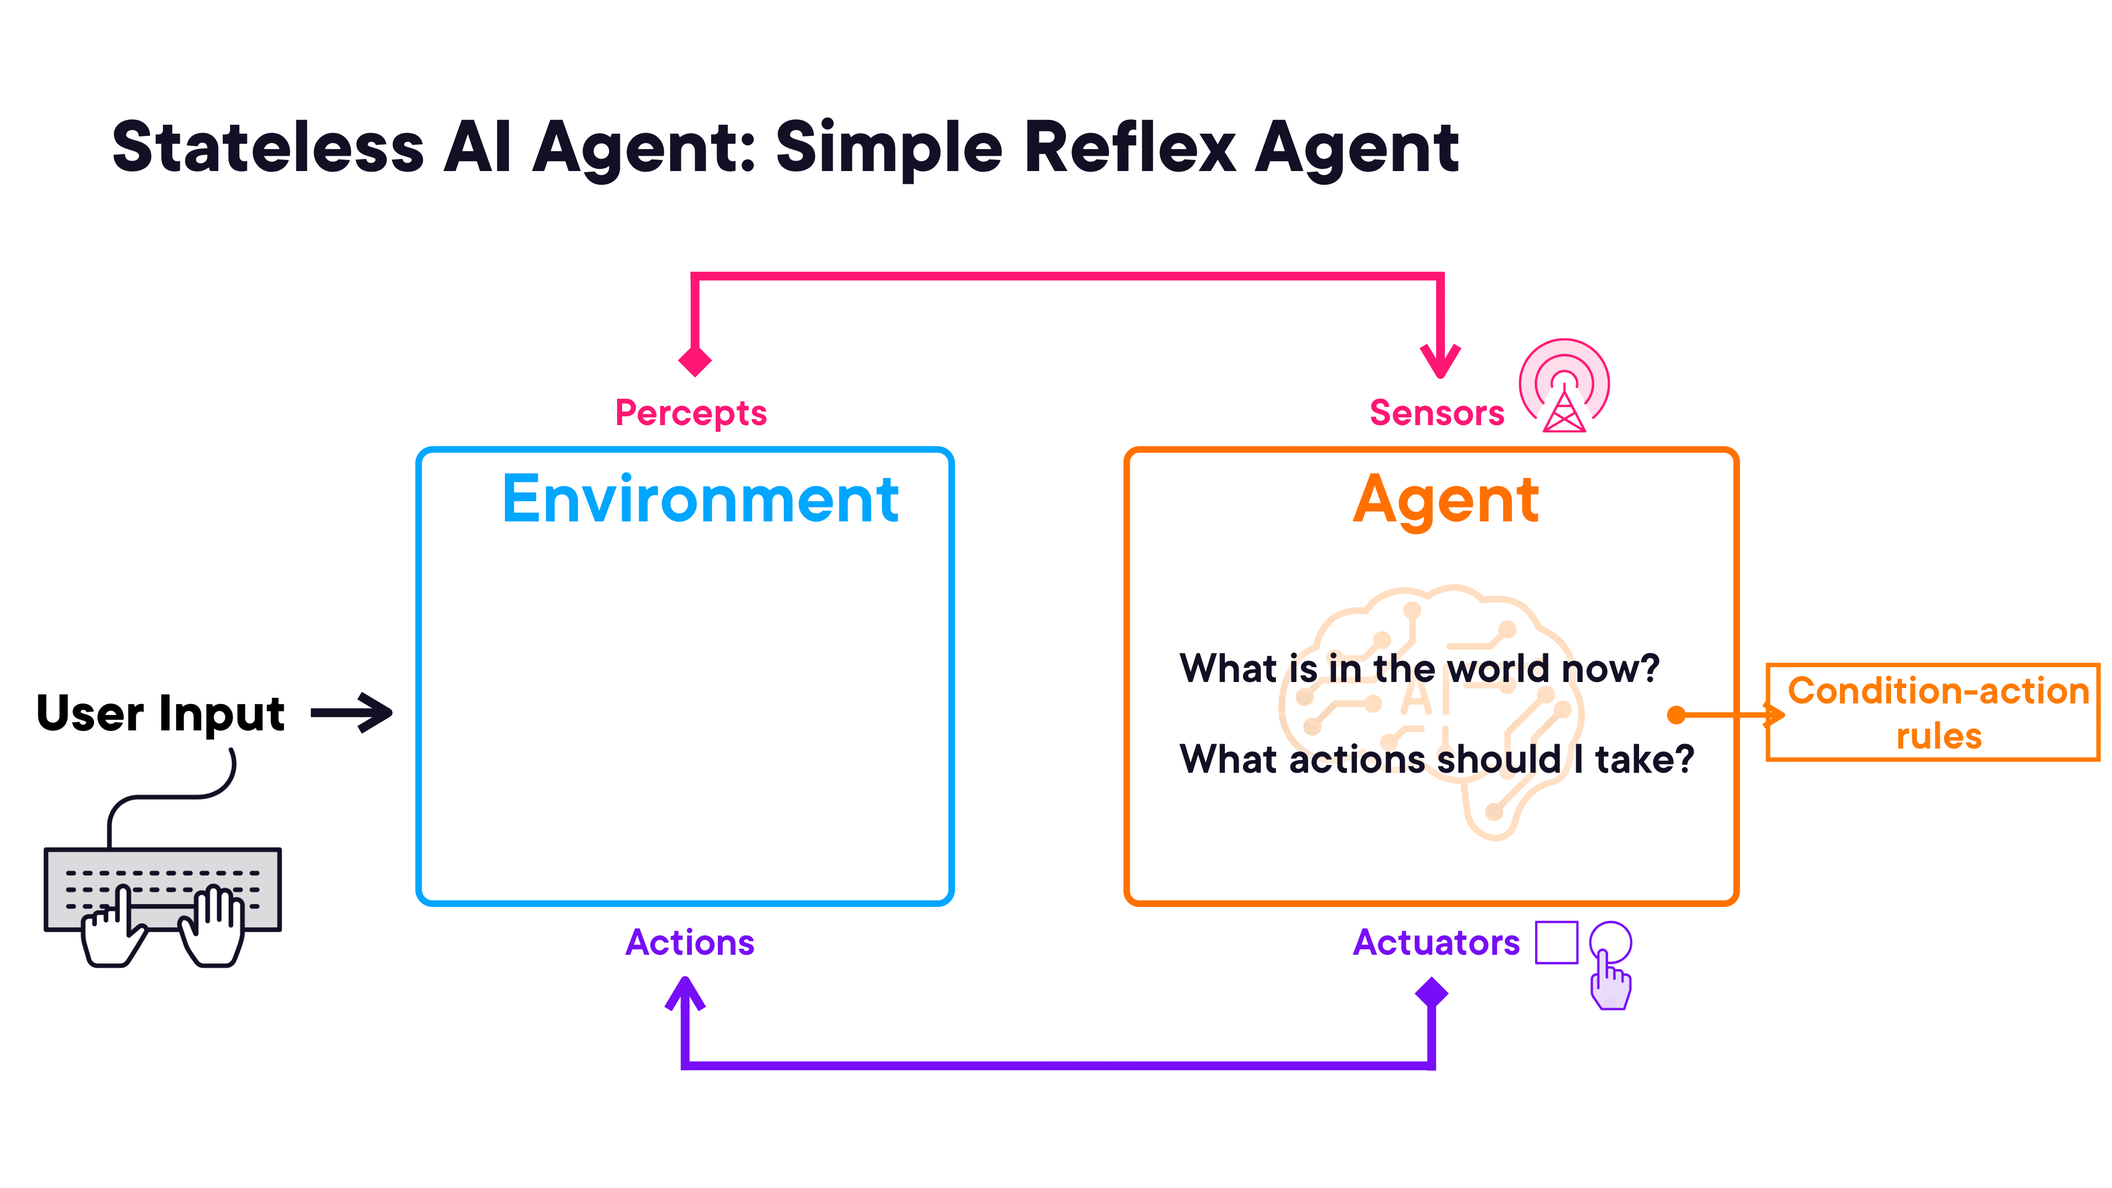

In [4]:
show('simple-reflex-agent.png', 55)

A **Simple Reflex Agent** maps current percepts directly to actions using condition-action rules:

```
IF <condition> THEN <action>
```

**Limitations:**
- Reacts to current percepts only — no past state
- Limited knowledge; non-adaptive to environment changes
- Same input always produces the same output

### Memory-Augmented Agent


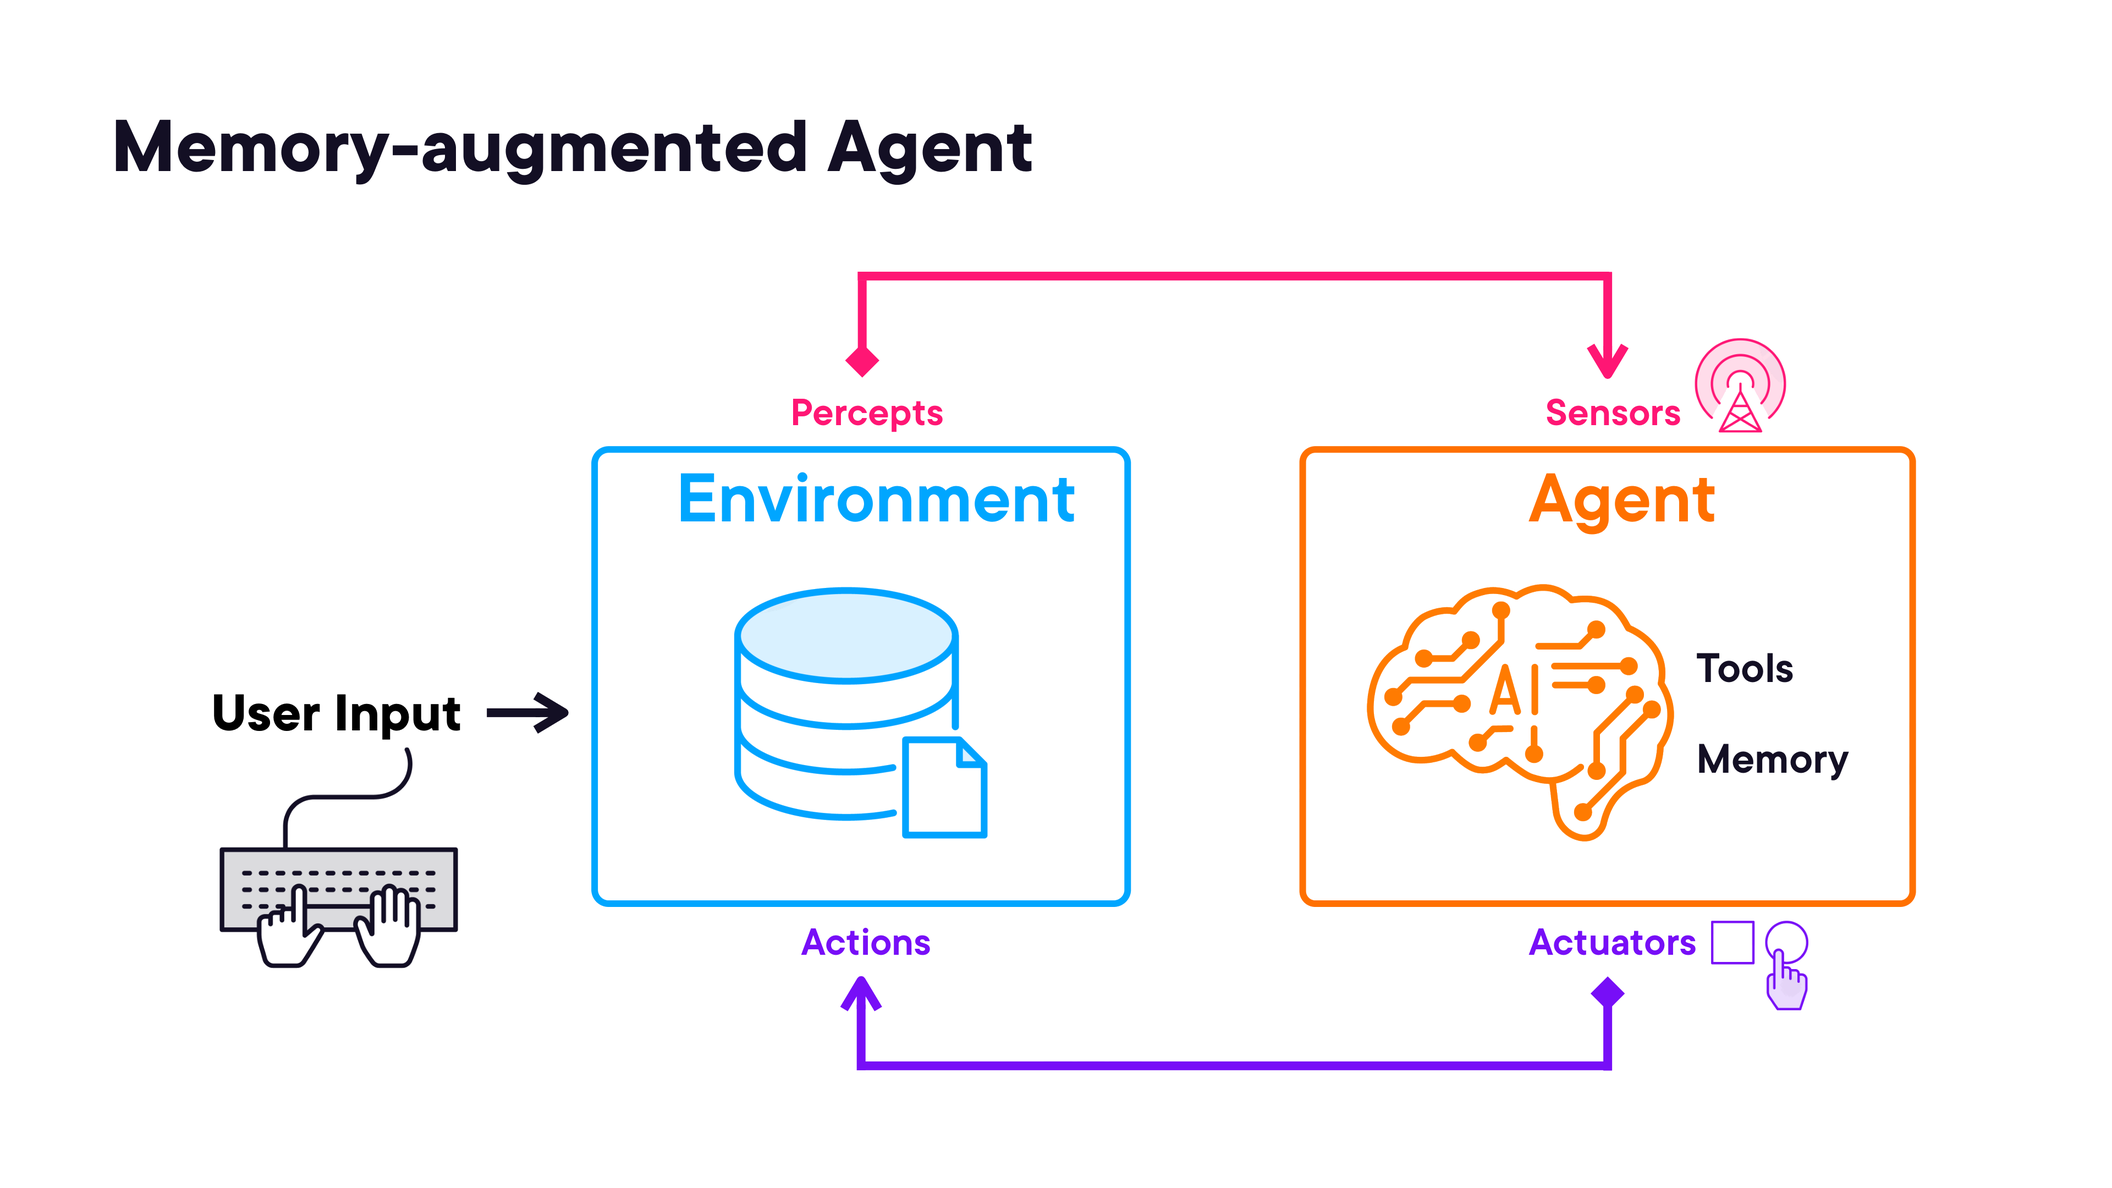

In [5]:
show('memory-augmented-agent.png', 55)

Adding **Tools** and **Memory** to the agent unlocks a qualitatively different class of behavior:

| Aspect | Stateless Agent | Memory-Augmented Agent |
|--------|-----------------|------------------------|
| Context | Current percepts only | Full history + retrieved context |
| Architecture | Simple, fixed rules | Flexible and customizable |
| Adaptability | Non-adaptive, predictable | Adaptive and dynamic |
| Personalization | None | Remembers user preferences |
| Multi-step tasks | Cannot continue | Can resume interrupted tasks |
| Output quality | Faster, simpler | Slower, more accurate |

### Types of Memory

Human memory research maps directly onto agentic AI memory design:

| Memory Type | Human Analogy | Characteristics | AI Implementation | Example |
|-------------|---------------|-----------------|-------------------|---------|
| **Episodic** | Personal experiences | Specific, personal, contextual | Conversation history / Vector DB | *Yesterday I debugged an issue on the user report* |
| **Semantic** | General world knowledge | Common, non-contextual, factual | Vector DB (RAG) | *Pandas is a Python library / Coding standards* |
| **Procedural** | Skills and how-to | Instructional, capability-based | System prompts / Tool definitions | *Act as a senior AI engineer / Ride a bike* |

### Memory Management: Limitations

Even with memory, LLMs face hard constraints:

| Limitation | Description | Impact |
|-----------|-------------|--------|
| **Context window** | Fixed token limit (e.g. 200K for Claude) | Long conversations get truncated |
| **Latency** | Processing large contexts takes more time | Slower agent responses |
| **Token cost** | More tokens = higher API cost | Expensive at scale |
| **Lost in the middle** | LLMs attend poorly to middle-of-context content | Important history may be ignored |
| **No persistence** | Context disappears between sessions | Must be explicitly stored externally |

### Memory Management: Strategies

**Context and Memory Management Strategies:**

| Strategy | Description | Token Savings |
|----------|-------------|---------------|
| **Short + long-term storage** | Keep hot context in-window; persist cold memory to vector store | Architecture pattern |
| **Summarization** | Condense older turns into a rolling summary | ~70% |
| **Pruning** | Remove irrelevant or low-importance messages | ~40% |
| **Caching** | Reuse static prefix caches (Claude, GPT-4o) | ~50% on repeated calls |
| **RAG retrieval** | Only inject top-K semantically relevant memories | Variable |
| **Hybrid methods** | Combine multiple strategies for best results | Additive |

### Why Memory Matters: Benefits & Use Cases

**Persistent Memory enables agents to:**
- **Learn and improve** — refine behavior from past interactions
- **Retain context** — carry state across multi-step tasks and sessions
- **Adapt and personalize** — tailor responses to individual users
- **Collaborate** — share knowledge across agents toward collective goals

**Real-world Use Cases:**

| Use Case | Memory Role |
|----------|-------------|
| Conversational AI Assistant | Remembers preferences, prior topics, user profile |
| Customer / Technical Support | Retains ticket history and past resolutions |
| Multi-step Agentic Automation | Picks up interrupted workflows across sessions |
| Research AI Workflow | Accumulates and queries a growing knowledge base |

### Agentic Frameworks with Memory Support

| Framework | Primary Memory Approach | Best For |
|-----------|------------------------|----------|
| **Semantic Kernel** | Thread-based conversation history | Microsoft / .NET ecosystems |
| **Haystack** | Composable pipelines + external stores | Production RAG + memory |
| **MemGPT / Letta** | Managed memory blocks (core / archival) | Long-lived stateful agents |
| **LlamaIndex** | Index-based retrieval over documents | Complex document retrieval |
| **LangChain** | Buffer + vector store hybrid | Flexible, full ecosystem |

---
## Part 2: Comparing Techniques and Frameworks for Persistent Memory

### Agentic Workflow Evolution


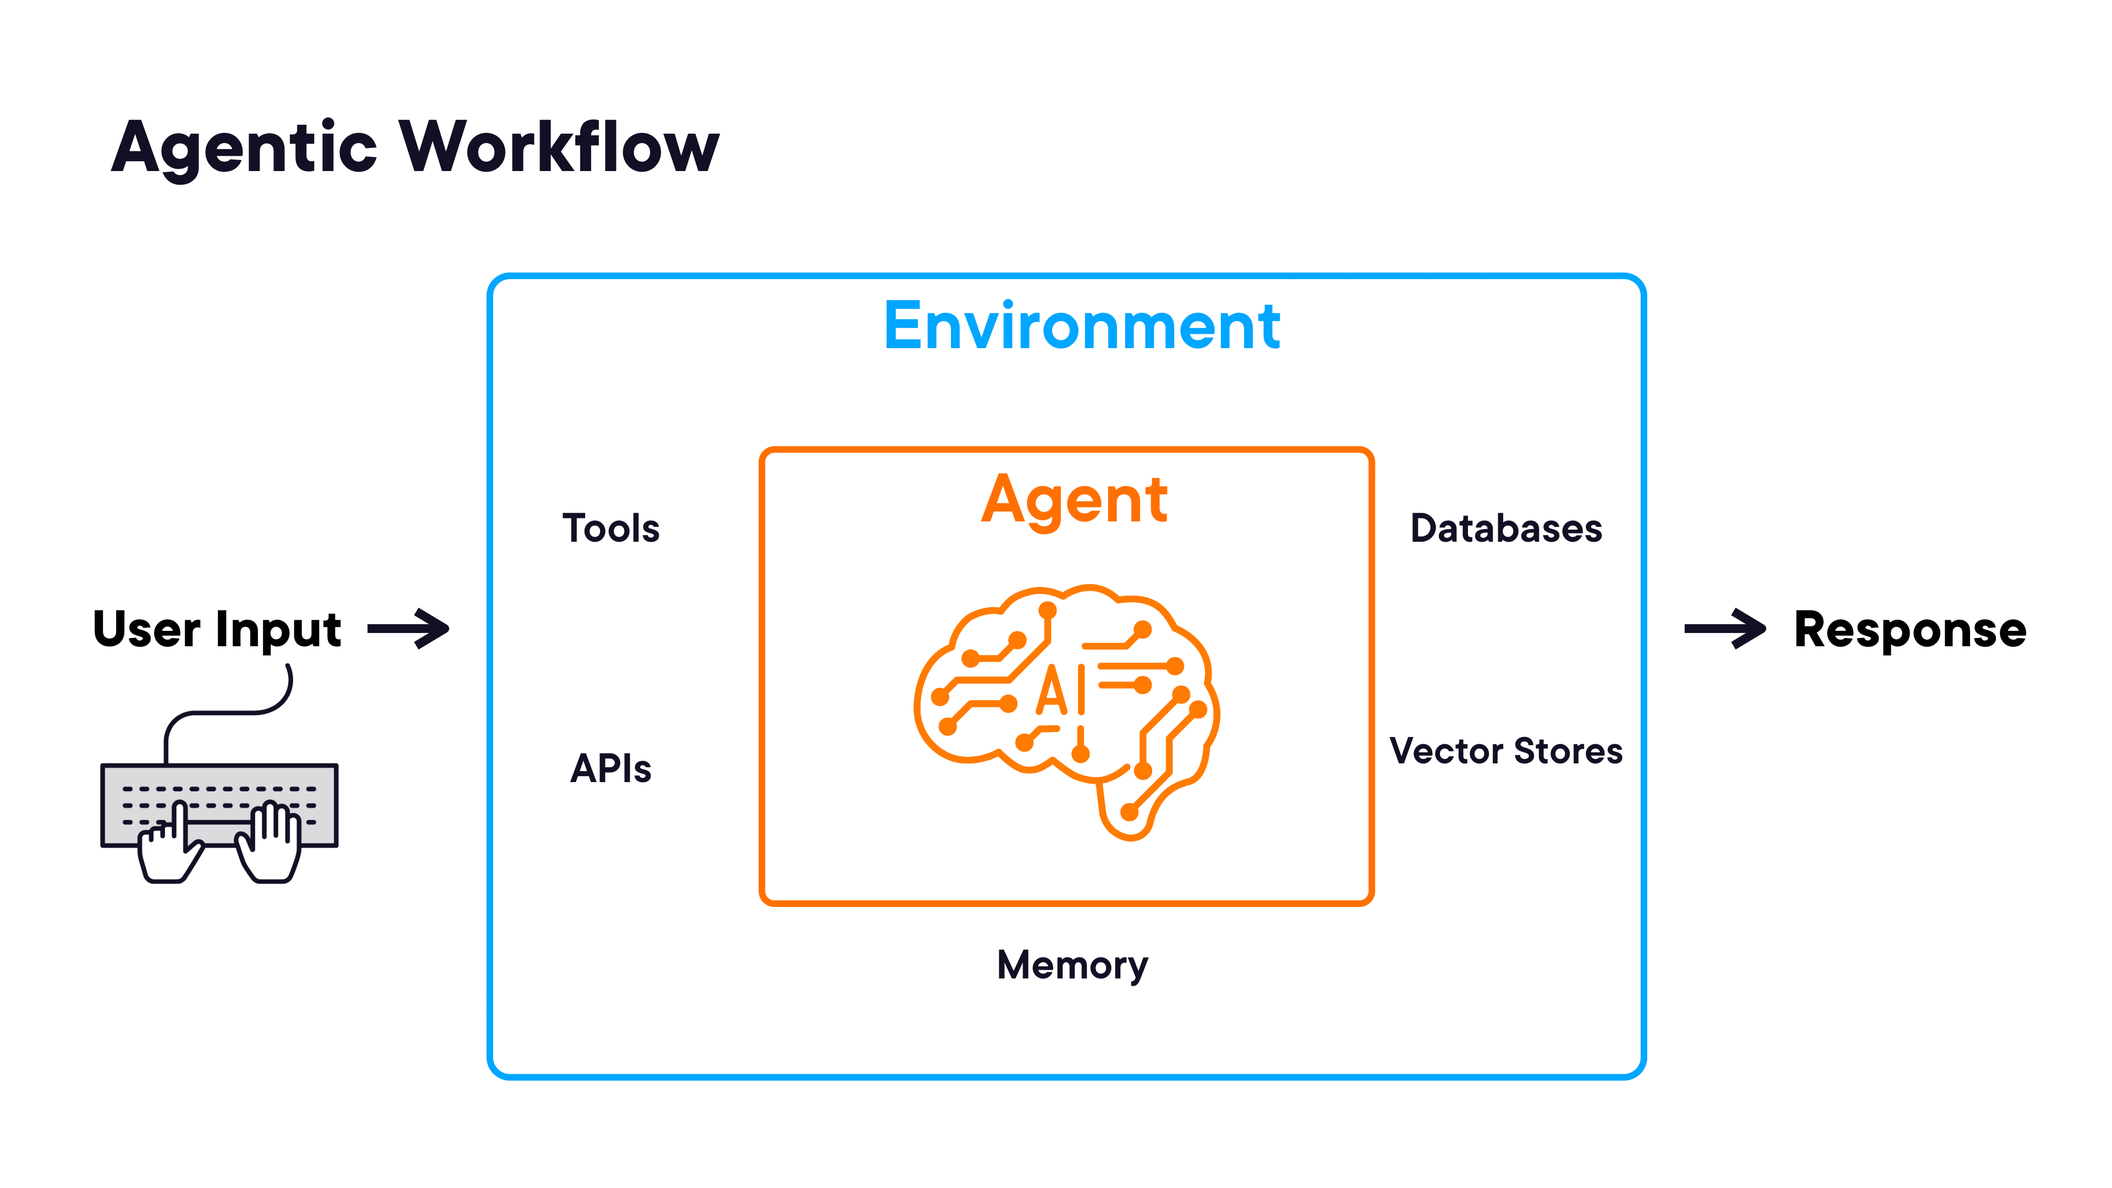

In [6]:
show('agentic-workflow-evolution.png', 55)

The progression from stateless LLM to fully persistent multi-agent systems:

```
LLM (stateless)
  └─> + Tools          (function calling)
        └─> + APIs       (external integrations)
              └─> + Databases  (persistent structured data)
                    └─> + Vector Stores + Memory  (semantic retrieval)
                          └─> Multi-agent + Shared Persistent Memory  ← Today
```

Each layer adds capability but also complexity. The key architectural insight: **memory must be treated as a first-class citizen**, not an afterthought.

### Agentic Workflow with Persistent Memory


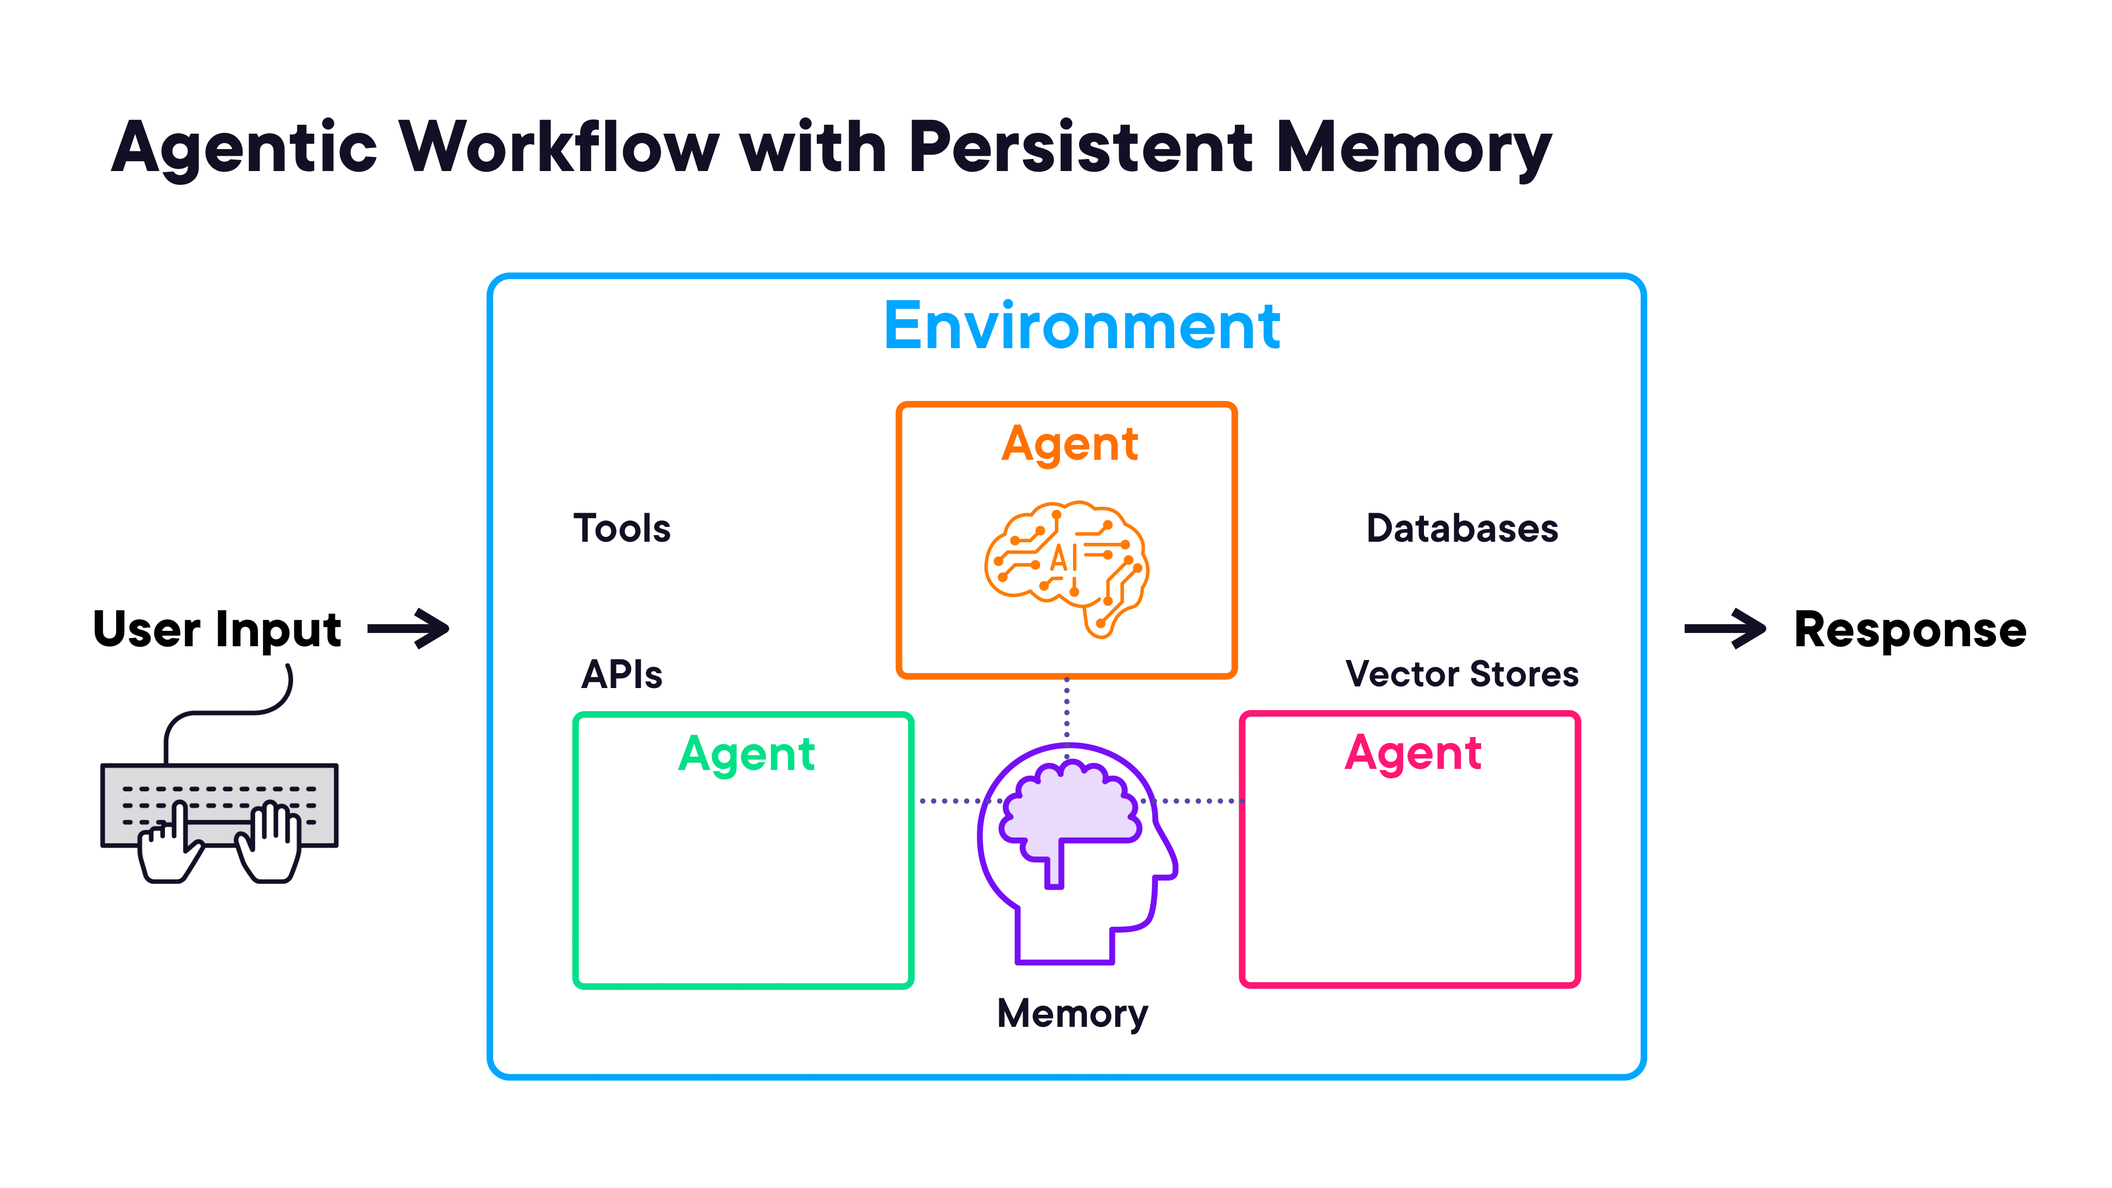

In [7]:
show('agentic-workflow-persistent-memory.png', 55)

In a fully memory-augmented multi-agent system:
- Multiple specialized agents share a common **Memory** layer
- Agents read and write via **Tools**, **APIs**, **Vector Stores**, and **Databases**
- A shared memory layer enables **context handoff** between agents
- Persistence ensures continuity **across sessions and reboots**

**Project scenario:** A Software Developer building an automated AI-powered engineering team — goals: *increasing efficiency, improving productivity, saving time and resources*.

### Semantic Kernel — Thread-based Memory

> Create AI agents designed to perform tasks autonomously and achieve specific goals.
> — [Microsoft Semantic Kernel Docs](https://learn.microsoft.com/sk-sk/semantic-kernel/frameworks/agent)

Semantic Kernel organizes memory around **threads** — persistent, serializable conversation containers.

**Setup flow:**
1. Initialize the kernel
2. Add AI service
3. Create a `ChatCompletionAgent`
4. Manage conversation history via a `ChatHistoryAgentThread`

**Request flow with memory:**
```
User Request → Agent / Orchestrator → External Services and APIs
                                             ↓
                                   Chat history (thread)  ← memory lives here
                                             ↓
                                          Response
```

```python
agent = ChatCompletionAgent(
    service_id="gpt-4o", kernel=kernel,
    name="MemoryAgent",
    instructions="You are a helpful assistant."
)
thread = ChatHistoryAgentThread()  # persists all turns
response = await agent.get_response(messages="Hello!", thread=thread)
```

`.env`:
```
OPENAI_API_KEY='sk-...'
```

### Mem0 — Managed Memory Layer

> Managed memory layer for AI agents. — [mem0.ai](https://mem0.ai/)

Mem0 transforms a **forgetful** (stateless) agent into a **learning** (stateful) one:


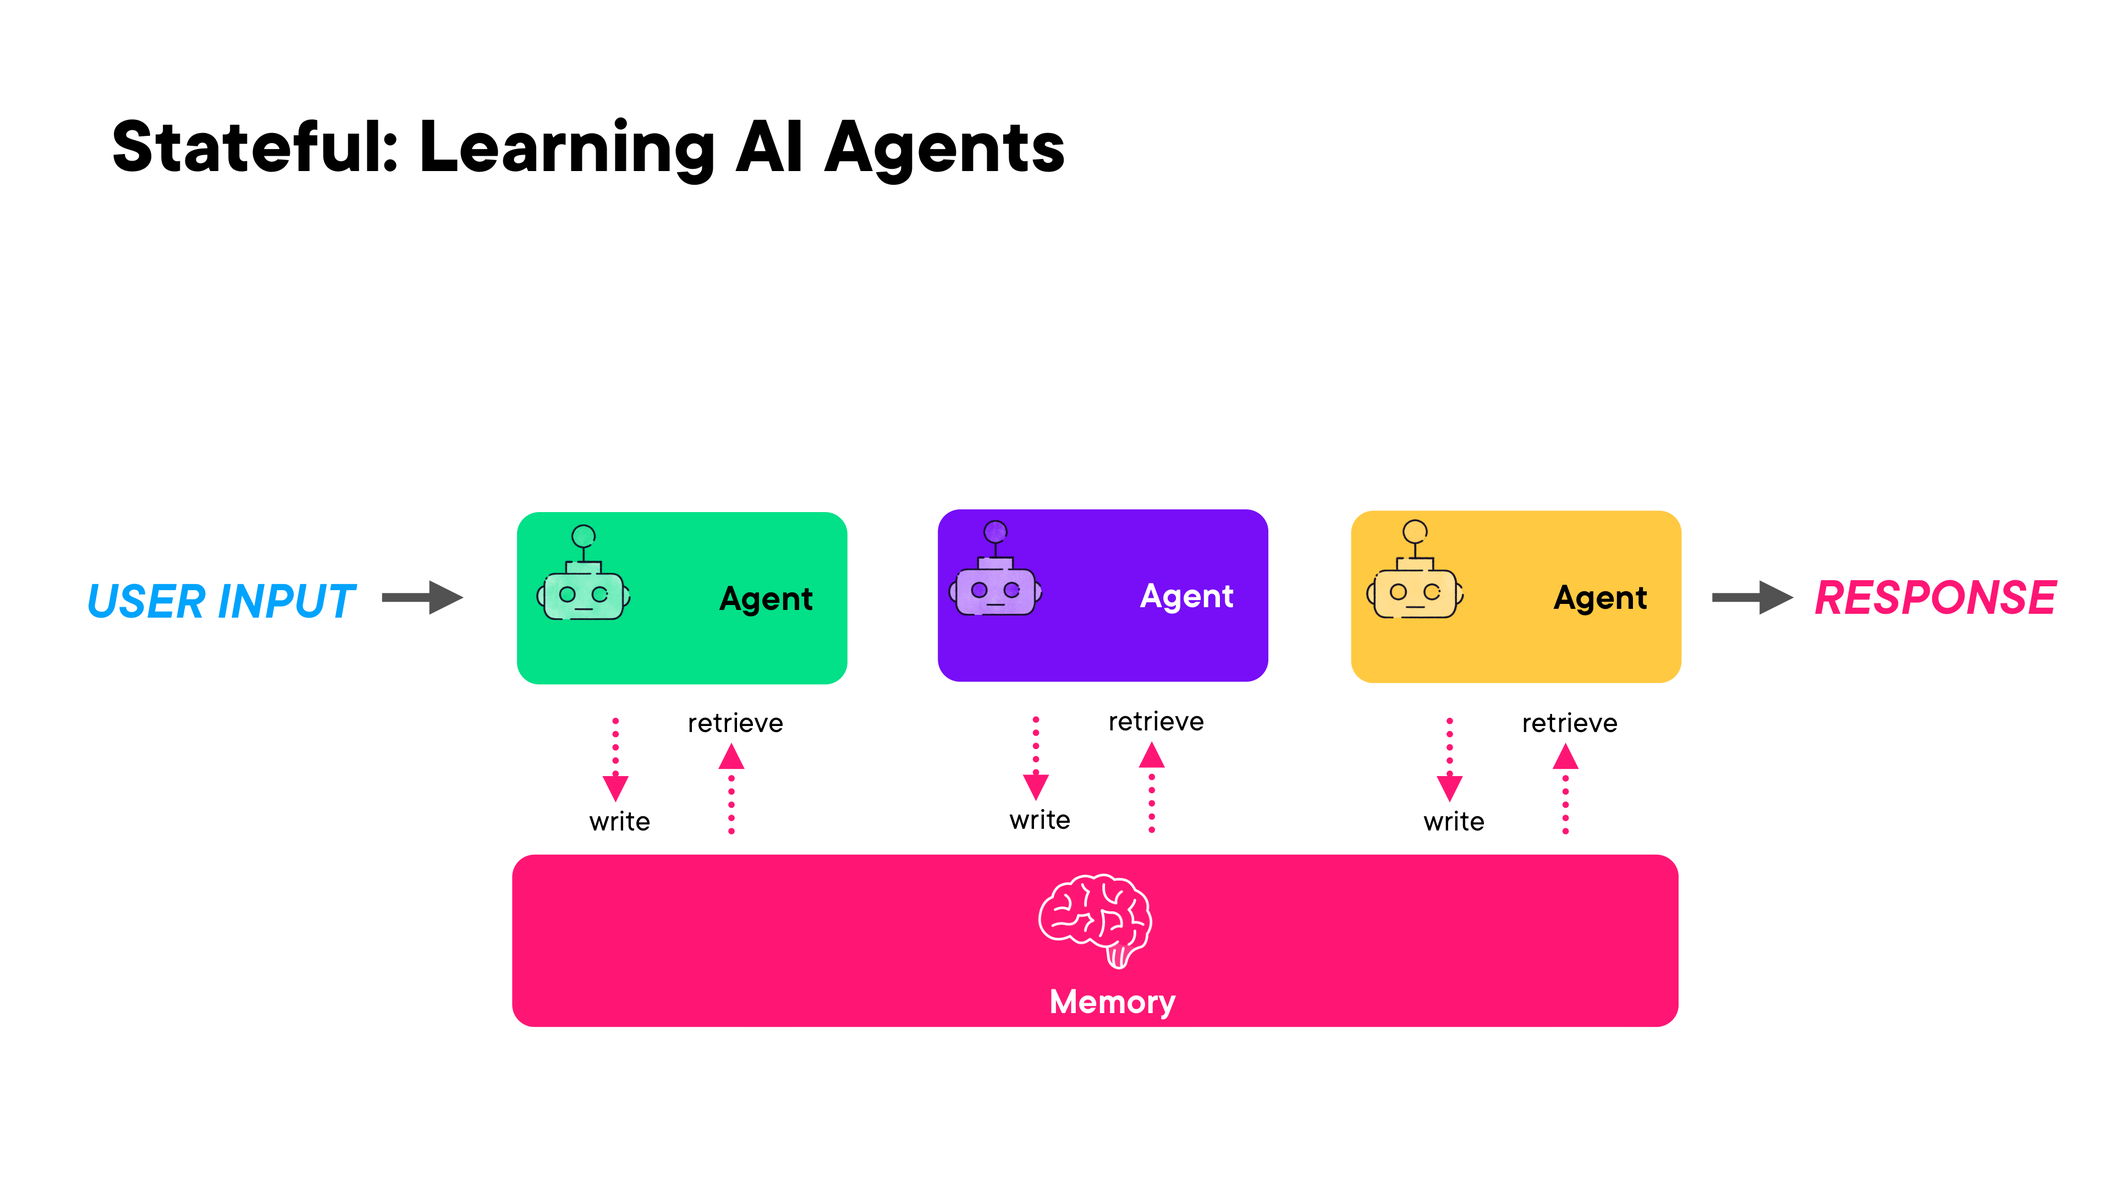

In [8]:
show('stateful-learning-agent.png', 55)

| Stateless (Forgetful) Agent | Stateful (Learning) Agent with Mem0 |
|-----------------------------|--------------------------------------|
| Forgets everything after each session | Remembers preferences and history |
| Treats every user as new | Personalizes based on past interactions |
| Cannot improve over time | Continuously learns and adapts |

**Getting started:**
```bash
pip install mem0ai
```

```python
from mem0 import MemoryClient

client = MemoryClient(api_key="m0-...")

# Store a memory scoped to a user
client.add("User prefers Python over JavaScript", user_id="alice")

# Retrieve relevant memories before each LLM call
memories = client.search("programming preferences", user_id="alice")
```

`.env`:
```
MEM0_API_KEY='m0-...'
MEM0_USER_ID='user'
```

### Haystack — Production-grade AI Agents

> Open-source AI orchestration framework to build production-ready AI agents. — [haystack.deepset.ai](https://haystack.deepset.ai/overview/intro)

**Building a RAG Agent with Memory Awareness (Haystack + Mem0):**

1. Install required packages: `pip install haystack-ai mem0ai`
2. Create an API key for Mem0
3. Configure a memory store (Mem0)
4. Run the agent: retrieve memories → generate → save new memories

**Request flow with memory layer:**
```
User Request
     ↓
Agent / Orchestrator
     ↓
Vector Store (RAG)          ← semantic document retrieval
     ↓
Memory Layer (Mem0)         ← long-term episodic memory
     ↓
Response  →  save new memories to Mem0
```

### MemGPT / Letta — Stateful Agents with Memory Blocks

> Platform for building stateful agents that remember, learn, and improve over time. — [docs.letta.com](https://docs.letta.com/guides/get-started/intro)

**LLMs and Short-term Memory: Limitations**
- Context window constraints with loss and errors
- Latency and slow responses
- High cost & token usage

MemGPT solves this with **structured memory blocks** — each with a distinct role and lifespan:

| Memory Block | Always In Context | Description | Analogous To |
|-------------|:-----------------:|-------------|---------------|
| **Core Memory** | ✅ | Persona, user facts — always injected | RAM / Working memory |
| **Recall Memory** | ❌ | Searchable conversation history | Short-term storage |
| **Archival Memory** | ❌ | Long-term vector store of anything | Hard disk / Long-term storage |

**Creating Agents with Memory Blocks:**
1. Initialize client
2. Create an agent
3. Create a shared memory block
4. Run and access the shared memory

```python
from letta import create_client
from letta.schemas.memory import BasicBlockMemory

client = create_client()
agent = client.create_agent(
    name="PersistentCoder",
    memory=BasicBlockMemory(blocks=[
        client.create_block(label="persona", value="Expert Python developer"),
        client.create_block(label="human",   value="The user is a senior engineer")
    ])
)
```

`.env`:
```
LETTA_API_KEY='sk-...'
```

### Memory Types in Agentic Applications

**Overcoming Short-term Memory Limitations:**
- Hybrid search methods
- Long-term memory storage (Vector Store)
- Retrieval-Augmented Generation (RAG)
- Memory summarization and pruning

**Memory types mapped to agentic implementations:**

| Memory Type | Characteristics | Agentic Example | Storage | Retrieval |
|-------------|-----------------|-----------------|---------|----------|
| **Episodic** | Specific, personal, contextual | *Yesterday I debugged a user report issue* | Conversation history → **Vector DB** | Semantic similarity |
| **Semantic** | General, factual, non-contextual | *Coding standards / Documentation* | **Vector DB (RAG)** | Semantic similarity |
| **Procedural** | Skills, instructions, capabilities | *Act as a senior AI engineer* | **System Prompts / Tools** | Direct injection |

### LlamaIndex — Building an Engineering AI Team

> Leading framework for building LLM-powered agents and event-driven workflows. — [developers.llamaindex.ai](https://developers.llamaindex.ai/python/framework/)

**Building an Engineering Agent Team:**
- **Automated Code Completion and Review Workflow** — orchestrating multi-agent AI systems
- **Improved memory management** — context shared across agents
- **Integrated RAG** — agents query project documentation and codebase
- **Persistent memory** — project context survives session restarts

---
## Part 3: End-to-end Demo — Multi-agent System with Persistent Memory

### Engineering Multi-agent AI Team

**Goal:** Build an automated multi-agent engineering team using LangChain + LangGraph + ChromaDB.

| Objective | Description |
|-----------|-------------|
| **Efficiency** | Automate repetitive coding, review, and documentation tasks |
| **Productivity** | Agents work in parallel on different parts of the codebase |
| **Reliability** | Each agent's output is validated by a dedicated checker agent |
| **Scalability** | New specialized agents can be added without redesigning the system |
| **Security** | Memory scoped per user / project — no cross-contamination |

**Memory Techniques and Strategies:**
- Multi-agent orchestration with shared memory
- Hybrid memory: short-term (buffer) + long-term (vector store) + RAG
- Memory compression, summarization, and pruning
- Caching and cost optimization
- Low latency and scalable deployment

### LangChain: Hybrid Memory Architecture

**LangChain: Hybrid Memory Strategies and Techniques**

```
┌──────────────────────────────────────────────────┐
│               Agent Context Window               │
│                                                  │
│  ┌─────────────────────┐  ┌────────────────────┐ │
│  │    Short-term        │  │    Long-term        │ │
│  │  ConversationBuffer  │  │  ChromaDB Vector    │ │
│  │  WindowMemory (k=N)  │  │  Store (persistent) │ │
│  │  + LangGraph thread  │  │  + RAG retrieval    │ │
│  └─────────────────────┘  └────────────────────┘ │
│            ↑                        ↑             │
│         Pruning /             Summarization /     │
│         Sliding window         Caching            │
└──────────────────────────────────────────────────┘
```

| Layer | Mechanism | Scope |
|-------|-----------|-------|
| Short-term | `ConversationBufferWindowMemory` + LangGraph thread | Recent N turns |
| Long-term | ChromaDB vector store (persistent on disk) | Across sessions |
| Optimization | Summarization + pruning + prompt caching | Context window budget |

### Installation and Setup

```bash
# Mac
python3 -m venv env && source env/bin/activate
pip3 install -r requirements.txt

# Windows
python -m venv env && .\env\Scripts\activate
pip install -r requirements.txt
```

**`requirements.txt`** (key dependencies):
```
langchain
langchain-openai
langchain-anthropic
langgraph
chromadb
python-dotenv
langsmith
```

**`.env`**:
```
OPENAI_API_KEY='sk-...'
LANGSMITH_TRACING=true
LANGSMITH_API_KEY='ls__...'
LANGSMITH_PROJECT='memory-agents-demo'
```

### Managing Short-term Memory

**Managing Short-term and Long-term Memory** — Add short-term memory with a conversation buffer and thread-level persistence.

```python
from langchain.memory import ConversationBufferWindowMemory
from langgraph.checkpoint.memory import MemorySaver

# Sliding window — keep last K exchanges in context
short_term = ConversationBufferWindowMemory(k=10, return_messages=True)

# Thread-based persistence: each thread_id = isolated conversation
checkpointer = MemorySaver()
graph = graph_builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "project-alpha-session-1"}}
result = graph.invoke({"messages": user_input}, config=config)
# Resume the same conversation later with the same thread_id
```

### LangGraph Long-term Memory with ChromaDB

**LangGraph Long-term Memory Persistence** — Enabling semantic search and fast retrieval with ChromaDB (vector store).

```python
import chromadb
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings

# Persistent client — survives process restarts
client = chromadb.PersistentClient(path="./chroma_db")
vectorstore = Chroma(
    client=client,
    collection_name="agent_long_term_memory",
    embedding_function=OpenAIEmbeddings()
)

# Write a memory
vectorstore.add_texts(
    texts=["User prefers async Python patterns"],
    metadatas=[{"user_id": "alice", "timestamp": "2024-01-15"}]
)

# Retrieve top-5 relevant memories before each LLM call
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
memories = retriever.invoke("code style preferences")
```

### High Performance and Production-grade Scaling

**Optimizing memory storage and retrieval: summarizing, pruning, compressing, and caching.**

```python
from langchain_core.messages import SystemMessage

def optimize_memory(messages, llm, max_tokens=2000):
    """Summarize old messages when context grows too large."""
    if count_tokens(messages) > max_tokens:
        old_messages = messages[:-5]  # preserve last 5 turns as-is
        summary = llm.invoke(
            f"Summarize this conversation history concisely:\n{old_messages}"
        )
        return [SystemMessage(content=summary.content)] + messages[-5:]
    return messages
```

| Technique | Description | Token Savings |
|-----------|-------------|---------------|
| **Rolling summarization** | Replace oldest turns with an LLM-generated summary | ~70% |
| **Pruning** | Drop low-relevance messages below a threshold | ~40% |
| **Prompt caching** | Cache static system-prompt prefix (Claude, GPT-4o) | ~50% |
| **Selective retrieval** | Inject only top-K semantically relevant memories | Variable |

### Testing and Monitoring with LangSmith

**Testing and Monitoring Performance** — Tracing agents' responses, monitoring token usage and latency.

**LangSmith** provides full observability for LangChain / LangGraph apps:

| Feature | Description |
|---------|-------------|
| **Traces** | Every LLM call, tool use, and retrieval is automatically logged |
| **Evaluations** | Test memory retrieval quality with automated evals and datasets |
| **Monitoring** | Track latency, cost, and error rates in production |
| **Datasets** | Build golden test sets from real production traffic |

```bash
# Enable via .env — zero code changes needed
LANGSMITH_TRACING=true
LANGSMITH_API_KEY=ls__...
LANGSMITH_PROJECT=my-memory-agent
# All LangChain calls are automatically traced → view at smith.langchain.com
```

### Next Steps — Production Vector Databases

**Next Steps** — Production vector databases: Redis · Pinecone · Weaviate · PostgreSQL · Elasticsearch

ChromaDB is ideal for development and prototyping. For production-scale deployments, swap it out via the LangChain `VectorStore` interface:

| Vector DB | Strengths | Best For |
|-----------|-----------|----------|
| **Redis** | Ultra-low latency, in-memory | Real-time memory, session caching |
| **Pinecone** | Fully managed, auto-scaling, rich metadata filtering | Enterprise production |
| **Weaviate** | Hybrid vector + BM25 keyword search, GraphQL | Multi-modal, complex retrieval |
| **PostgreSQL (pgvector)** | SQL + vector in one database | Existing Postgres infrastructure |
| **Elasticsearch** | Full-text + vector hybrid, widely adopted | Search-heavy applications |

```python
# Swap ChromaDB for Pinecone with minimal changes
from langchain_pinecone import PineconeVectorStore

vectorstore = PineconeVectorStore(
    index_name="agent-memory",
    embedding=OpenAIEmbeddings()
)
# retriever interface is identical — no other code changes needed
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})
```

---
### Course Summary

| Topic | Key Takeaway |
|-------|-------------|
| **Why memory** | LLMs are stateless by default — memory unlocks continuity, personalization, and multi-step reasoning |
| **Memory types** | Episodic (events) → Vector DB; Semantic (facts) → RAG; Procedural (skills) → System Prompts |
| **Short-term limits** | Context window, latency, cost — must be managed with summarization, pruning, caching |
| **Stateless vs stateful** | Stateful agents learn and adapt across sessions; stateless restart from zero every time |
| **Semantic Kernel** | Thread abstraction wraps full conversation history — serializable and resumable |
| **Mem0** | Managed memory-as-a-service — stores and retrieves per-user memories automatically |
| **Haystack** | Production RAG pipelines with Mem0 as a pluggable long-term memory layer |
| **MemGPT / Letta** | Structured memory blocks: Core (always in context), Recall, Archival |
| **LangChain hybrid** | Short-term `ConversationBufferWindowMemory` + long-term ChromaDB vector store |
| **Optimization** | Summarize → prune → cache → retrieve selectively — control token budget |
| **Observability** | LangSmith traces every call — essential for debugging and eval in production |
| **Production DBs** | Redis, Pinecone, Weaviate, pgvector, Elasticsearch — all swap in via same interface |

> **The future of AI is memory-augmented.** Agents that remember are agents that can truly help.